# Music Support Bot Notebook

## Setup

In [13]:
import operator
import sqlite3
import textwrap
from enum import Enum
from typing import Annotated, Literal

import requests
from IPython.display import Image, display
from langchain_community.utilities.sql_database import SQLDatabase
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI

from langchain_core.messages import SystemMessage, HumanMessage


from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, interrupt
from pydantic import BaseModel, Field
from sqlalchemy import create_engine, text
from sqlalchemy.pool import StaticPool

In [14]:

# Database setup
def get_engine_for_chinook_db():
    """Pull sql file, populate in-memory database, and create engine."""
    url = "https://raw.githubusercontent.com/lerocha/chinook-database/master/ChinookDatabase/DataSources/Chinook_Sqlite.sql"
    response = requests.get(url)
    sql_script = response.text

    connection = sqlite3.connect(":memory:", check_same_thread=False)
    connection.executescript(sql_script)
    return create_engine(
        "sqlite://",
        creator=lambda: connection,
        poolclass=StaticPool,
        connect_args={"check_same_thread": False},
    )


engine = get_engine_for_chinook_db()
db = SQLDatabase(engine)


def fetch_songs_by_genre(genre_name: str) -> list[dict]:
    """Internal helper: query songs by genre, returns list of dicts."""
    with engine.connect() as conn:
        result = conn.execute(
            text("""
                SELECT
                    t.TrackId AS track_id,
                    t.Name AS track_name,
                    g.Name AS genre_name,
                    al.Title AS album_title,
                    ar.Name AS artist_name,
                    t.Composer AS composer,
                    t.Milliseconds AS milliseconds,
                    t.Bytes AS bytes,
                    t.UnitPrice AS unit_price
                FROM Track t
                JOIN Genre g ON t.GenreId = g.GenreId
                LEFT JOIN Album al ON t.AlbumId = al.AlbumId
                LEFT JOIN Artist ar ON al.ArtistId = ar.ArtistId
                WHERE g.Name LIKE :genre
                ORDER BY RANDOM()
                LIMIT 10
            """),
            {"genre": f"%{genre_name}%"},
        )
        return [dict(row._mapping) for row in result]


@tool
def recommend_songs_by_genre(genre: str):
    """Recommend songs by genre."""
    print(f"recommend_songs_by_genre: {genre}")
    return db.run(
        f"""
        SELECT Track.Name as SongName, Genre.Name as GenreName
        FROM Track
        LEFT JOIN Genre ON Track.GenreId = Genre.GenreId
        WHERE Genre.Name LIKE '%{genre}%';
        """,
        include_columns=True,
    )


@tool
def get_albums_by_artist(artist: str):
    """Get albums by an artist."""
    print(f"get_albums_by_artist: {artist}")
    return db.run(
        f"""
        SELECT * FROM public.artist
        ORDER BY artist_id ASC 
        """,
        include_columns=True,
    )


@tool
def get_tracks_by_artist(artist: str):
    """Get songs by an artist (or similar artists)."""
    print(f"get_tracks_by_artist: {artist}")
    return db.run(
        f"""
        SELECT Track.Name as SongName, Artist.Name as ArtistName
        FROM Album
        LEFT JOIN Artist ON Album.ArtistId = Artist.ArtistId
        LEFT JOIN Track ON Track.AlbumId = Album.AlbumId
        WHERE Artist.Name LIKE '%{artist}%';
        """,
        include_columns=True,
    )


@tool
def check_for_songs(song_title: str):
    """Check if a song exists by its name."""
    print(f"check_for_songs: {song_title}")
    return db.run(
        f"""
        SELECT * FROM Track WHERE Name LIKE '%{song_title}%';
        """,
        include_columns=True,
    )


@tool
def check_for_songs_by_genre(genre_name: str):
    """Check for songs that belong to a genre by genre name."""
    print(f"check_for_songs_by_genre: {genre_name}")
    return fetch_songs_by_genre(genre_name)



In [15]:
# Music related models and constants

genre_names = [
    "Rock",
    "Jazz",
    "Metal",
    "Alternative & Punk",
    "Rock And Roll",
    "Blues",
    "Latin",
    "Reggae",
    "Pop",
    "Soundtrack",
    "Bossa Nova",
    "Easy Listening",
    "Heavy Metal",
    "R&B/Soul",
    "Electronica/Dance",
    "World",
    "Hip Hop/Rap",
    "Science Fiction",
    "TV Shows",
    "Sci Fi & Fantasy",
    "Drama",
    "Comedy",
    "Alternative",
    "Classical",
    "Opera",
]


class GenreExtraction(BaseModel):
    genres: list[str] | None = Field(
        default=None,
        description="List of music genres identified from the message",
    )


class SongDocument(BaseModel):
    track_id: int
    track_name: str
    genre_name: str | None = None
    album_title: str | None = None
    artist_name: str | None = None
    composer: str | None = None
    milliseconds: int | None = None
    bytes: int | None = None
    unit_price: float | None = None


class MusicQuery(BaseModel):
    artist: list[str] | None = Field(
        default=None, description="The names of artists mentioned in the message"
    )
    album: list[str] | None = Field(
        default=None, description="The names of albums mentioned in the message"
    )
    song: list[str] | None = Field(
        default=None, description="The names of songs mentioned in the message"
    )
    genre: list[str] | None = Field(
        default=None, description="The genres of music mentioned in the message"
    )

In [16]:
# Customer support models and constants

class CustomerDocument(BaseModel):
    customer_id: int
    first_name: str
    last_name: str
    company: str | None = None
    address: str | None = None
    city: str | None = None
    state: str | None = None
    country: str | None = None
    postal_code: str | None = None
    phone: str | None = None
    fax: str | None = None
    email: str
    support_rep_id: int | None = None

In [17]:
# General models and constants

class MessageClassification(BaseModel):
    intent: Literal["parse_music_query", "customer_support_query", "other"]


class MessageAgentState(BaseModel):
    # Raw message data
    message_content: str
    followup_message: str | None = None
    message_id: int
    sender_number: str

    # Classification result
    message_classification: MessageClassification | None = None

    # Music query
    music_query: MusicQuery | None = None
    song_recommendations: Annotated[list[SongDocument], operator.add] = Field(
        default_factory=list
    )

    # Agent message
    agent_message: str | None = None

    # Customer support
    customer_first_name: str | None = None
    customer_last_name: str | None = None
    customer_verified: bool = False
    customer_document: CustomerDocument | None = None

## Define Nodes

In [18]:
# Setup LLM
reasoning = {
    "effort": "low",  # 'low', 'medium', or 'high'
    "summary": None,  # 'detailed', 'auto', or None
}

llm = ChatOpenAI(model="gpt-5-nano", reasoning=reasoning)

In [19]:
def extract_text(message) -> str:
    """Extract plain text from an LLM response, handling reasoning model content blocks."""
    content = message.content if hasattr(message, "content") else message
    if isinstance(content, str):
        return content
    if isinstance(content, list):
        return "\n".join(
            block["text"]
            for block in content
            if isinstance(block, dict) and block.get("type") == "text"
        ).strip()
    return str(content)


In [20]:
# -----------------------------------------------------------------------------
# Classify intent
# -----------------------------------------------------------------------------


def classify_intent(state: MessageAgentState) -> MessageAgentState:
    """Use LLM to classify email intent and urgency, then route accordingly"""

    # Create structured LLM that returns MessageClassification
    structured_llm = llm.with_structured_output(MessageClassification)

    classification_prompt = textwrap.dedent(
        f"""
    Analyze this customer message and classify it:

    Message: {state.message_content}

    Provide a classification:
    - intent: either "parse_music_query" or "customer_support_query" or "other"

    parse_music_query: user is asking about music, artists, albums, or playlists
    customer_support_query: user is asking for help with their account, billing, or technical issues
    other: if the message doesn't fit either category or is too vague to classify
    """
    )

    # Get structured output from LLM
    message_classification = structured_llm.invoke(classification_prompt)
    state.message_classification = message_classification

    print("Message classification:", state.message_classification)

    return state


def route_after_classification(
    state: MessageAgentState,
) -> Literal["customer_support_query", "parse_music_query", "__end__"]:
    if (
        state.message_classification
        and state.message_classification.intent == "customer_support_query"
    ):
        return "customer_support_query"
    if (
        state.message_classification
        and state.message_classification.intent == "parse_music_query"
    ):
        return "parse_music_query"
    return END


# -----------------------------------------------------------------------------
# Music recommendation query parsing
# -----------------------------------------------------------------------------


def parse_music_query(state: MessageAgentState) -> dict:
    structured_llm = llm.with_structured_output(MusicQuery)

    prompt = textwrap.dedent(
        f"""
        You are extracting structured music query information from a user message.

        Your job is to extract only the music entities and genres the user wants recommendations based on.

        Message:
        {state.message_content}

        Extract the following fields:
        - artist: the artists the user wants music based on, or None
        - album: the albums the user wants music based on, or None
        - song: the songs the user wants music based on, or None
        - genre: the genres the user wants music based on, or None

        Important rules:
        - Only extract music entities or genres that the user is positively asking for or using as the reference point.
        - Ignore music entities or genres the user says they do NOT want, do NOT like, want to avoid, or do not want included.
        - Ignore negative examples, exclusions, and contrastive phrases.
        - Extract genres when the user explicitly asks for a genre, style, category, or broad music type.
        - Do not convert artists, albums, or songs into genres unless the user explicitly names the genre.
        - If the user mentions both entities and genres positively, extract all of them.

        Examples:
        - "Find me songs like Prince" -> artist=["Prince"], album=None, song=None, genre=None
        - "Recommend music like Thriller" -> artist=None, album=["Thriller"], song=None, genre=None
        - "Give me songs like Yellow" -> artist=None, album=None, song=["Yellow"], genre=None
        - "Find me music like Prince but not Michael Jackson" -> artist=["Prince"], album=None, song=None, genre=None
        - "I want songs like Purple Rain, not stuff by Aerosmith" -> artist=None, album=None, song=["Purple Rain"], genre=None
        - "Recommend albums like Rumours, but no U2" -> artist=None, album=["Rumours"], song=None, genre=None
        - "No jazz, give me music like Daft Punk" -> artist=["Daft Punk"], album=None, song=None, genre=None
        - "Songs like Bohemian Rhapsody and How Deep Is Your Love" -> artist=None, album=None, song=["Bohemian Rhapsody", "How Deep Is Your Love"], genre=None
        - "Music like Prince and Daft Punk" -> artist=["Prince", "Daft Punk"], album=None, song=None, genre=None
        - "Give me some rock songs" -> artist=None, album=None, song=None, genre=["Rock"]
        - "I want jazz and blues" -> artist=None, album=None, song=None, genre=["Jazz", "Blues"]
        - "Recommend pop music like Madonna" -> artist=["Madonna"], album=None, song=None, genre=["Pop"]
        - "No country, give me hip hop" -> artist=None, album=None, song=None, genre=["Hip Hop"]
        - "Find me electronic dance music" -> artist=None, album=None, song=None, genre=["Electronic Dance Music"]

        Extract ALL positive anchors mentioned. If multiple songs, artists, albums, or genres are positively referenced, include all of them.
        If no clear positive artist, album, song, or genre is present, return None for all fields.

        Return only the structured output.
        """
    )

    music_query = structured_llm.invoke(prompt)
    print("Parsed music query:", music_query)
    return {"music_query": music_query}


def get_song_recommendations(state: MessageAgentState) -> dict:
    # Skip the LLM call if parse_music_query found nothing useful
    mq = state.music_query
    has_info = mq and (mq.artist or mq.album or mq.song or mq.genre)
    if not has_info:
        print("No music query info — skipping genre extraction")
        return {"music_query": mq, "song_recommendations": []}

    structured_llm = llm.with_structured_output(GenreExtraction)
    prompt = textwrap.dedent(
        f"""
            You are identifying music genres for a recommendation engine.

            Available genres:
            {", ".join(genre_names)}

            The user's parsed music query is:
            {"Artists: " + ", ".join(mq.artist) if mq.artist else "No artists mentioned"}
            {"Albums: " + ", ".join(mq.album) if mq.album else "No albums mentioned"}
            {"Songs: " + ", ".join(mq.song) if mq.song else "No songs mentioned"}
            {"Genres already identified: " + ", ".join(mq.genre) if mq.genre else "No genres already identified"}

            Instructions:
            1. Keep any genres already identified in the query above.
            2. For each artist, album, and song listed, infer what genre(s) they belong to from the available genres list.
            3. Combine all genres (from step 1 and step 2) into a single list.
            4. Return each genre only once — no duplicates.
            5. Only use genres from the available genres list above.
            6. If no genres can be identified or inferred, return None.
        """
    )
    print("Extracting genres with prompt:", prompt)
    result = structured_llm.invoke(prompt)

    # Deduplicate while preserving order
    genres = list(dict.fromkeys(result.genres)) if result.genres else None
    print("Identified genres:", genres)

    updated_query = (
        state.music_query.model_copy(update={"genre": genres})
        if state.music_query
        else MusicQuery(genre=genres)
    )

    # Search for songs by genre
    search_results = []
    if genres:
        for genre in genres:
            songs = fetch_songs_by_genre(genre)
            print(f"Songs found for {genre}:", songs)
            for song in songs:
                search_results.append(SongDocument(**song))

    return {"music_query": updated_query, "song_recommendations": search_results}


def generate_song_recommendation_message(state: MessageAgentState) -> MessageAgentState:
    """Format song recommendations into a user-friendly message"""
    formatted_recommendations = []
    for result in state.song_recommendations:
        formatted_recommendations.append(
            f"{result.track_name} by {result.artist_name} (Genre: {result.genre_name}, Album: {result.album_title})"
        )

    if formatted_recommendations:
        original_message = state.message_content
        recommendations_text = "\n".join(formatted_recommendations)

        agent_message = llm.invoke(
            [
                SystemMessage(
                    content="""
                        You are a friendly music recommendation assistant.

                        Your job is to write a natural, engaging response to the user based on the user's original message and the recommended songs.
                        If there are multiple genres, please group songs by the genres and mention the genres in your response.
                        If there are multiple genres, limit each genre to 5 songs.

                        Instructions:
                        - Write a concise, warm, user-facing response
                        - Acknowledge the user's request naturally
                        - Present the recommendations in an easy-to-read way
                        - Keep the recommendations grounded only in the provided songs
                        - Do not invent songs, artists, albums, or genres
                        - Do not mention internal system details, tools, databases, or classification
                        - Use bullet points for the songs
                        - End with a light follow-up sentence inviting the user to ask for more
                        - Do not include extra analysis
                    """
                ),
                HumanMessage(
                    content=f"""
                        User's original message:
                        {original_message}

                        Recommended songs:
                        {recommendations_text}
                    """
                ),
            ]
        )

        state.agent_message = extract_text(agent_message)

    else:
        original_message = state.message_content
        agent_message = llm.invoke(
            [
                SystemMessage(
                    content="""
                        You are a friendly music recommendation assistant.

                        The user asked for music recommendations, but no songs were found that match the user's query.
                        Give a concise, warm response that acknowledges the user's request. Encourage the user to be more specific with their request, by suggesting a song, artist, album, or genre.

                        Instructions:
                        - Write a concise, warm, user-facing response
                        - Acknowledge the user's request naturally
                        - Present the recommendations in an easy-to-read way
                        - Keep the recommendations grounded only in the provided songs
                        - Do not invent songs, artists, albums, or genres
                        - Do not mention internal system details, tools, databases, or classification
                        - Use bullet points for the songs
                        - End with a light follow-up sentence inviting the user to ask for more
                        - Do not include extra analysis
                    """
                ),
                HumanMessage(content=f"""{original_message}"""),
            ]
        )

        if isinstance(agent_message.content, str):
            state.agent_message = agent_message.content
        else:
            text_blocks = []
            for _, block in enumerate(agent_message.content):
                if isinstance(block, dict) and block.get("type") == "text":
                    text = block.get("text", "")
                    text_blocks.append(text)
        state.agent_message = extract_text(agent_message)

    return state


In [21]:
# -----------------------------------------------------------------------------
# Customer support query
# -----------------------------------------------------------------------------


class CustomerName(BaseModel):
    first_name: str | None = None
    last_name: str | None = None


def get_customer_by_name(first_name: str, last_name: str):
    """Find a customer by first name and last name, case-insensitive."""
    print(f"get_customer_by_name: first_name={first_name}, last_name={last_name}")

    with engine.connect() as conn:
        result = conn.execute(
            text(
                """
                SELECT
                    CustomerId AS customer_id,
                    FirstName AS first_name,
                    LastName AS last_name,
                    Company AS company,
                    Address AS address,
                    City AS city,
                    State AS state,
                    Country AS country,
                    PostalCode AS postal_code,
                    Phone AS phone,
                    Fax AS fax,
                    Email AS email,
                    SupportRepId AS support_rep_id
                FROM Customer
                WHERE LOWER(FirstName) LIKE LOWER(:first_name)
                  AND LOWER(LastName) LIKE LOWER(:last_name)
                ORDER BY CustomerId
            """
            ),
            {"first_name": f"%{first_name}%", "last_name": f"%{last_name}%"},
        )
        return [dict(row._mapping) for row in result]


def extract_customer_name(message: str) -> CustomerName:
    """Extract customer first and last name from a message."""
    structured_llm = llm.with_structured_output(CustomerName)

    prompt = textwrap.dedent(
        f"""
        Extract the customer's first name and last name from the message.

        Message:
        {message}

        Rules:
        - Return the first name if clearly present
        - Return the last name if clearly present
        - If only one name is present, fill that as first_name and set last_name to None
        - If no name is clearly present, return None for both fields
        - Do not guess or invent names
        """
    )

    return structured_llm.invoke(prompt)


def has_full_customer_name(state: MessageAgentState) -> bool:
    return bool(state.customer_first_name and state.customer_last_name)


def route_after_customer_support_query(
    state: MessageAgentState,
) -> Literal["get_customer_info", "request_first_and_last_name"]:
    if has_full_customer_name(state):
        return "get_customer_info"
    return "request_first_and_last_name"


def route_after_request_first_and_last_name(
    state: MessageAgentState,
) -> Literal["get_customer_info", END]:
    if has_full_customer_name(state):
        return "get_customer_info"
    return END


def customer_support_query(state: MessageAgentState) -> MessageAgentState:
    """Check whether the customer support query already includes first and last name."""
    print("Handling customer support query for:", state.message_content)

    customer_name = extract_customer_name(state.message_content)
    state.customer_first_name = customer_name.first_name
    state.customer_last_name = customer_name.last_name

    print("Extracted customer name:", customer_name)

    if not has_full_customer_name(state):
        state.agent_message = (
            "Thank you for reaching out to customer support. "
            "Before I continue, please reply with your first and last name."
        )
        # Will route to request_first_and_last_name to wait for customer reply and extract name from there

    return state


def request_first_and_last_name(state: MessageAgentState) -> MessageAgentState:
    """Pause and ask the user for first and last name, then extract it from the reply."""
    print("Prompting for customer name. Current state:", state)

    customer_response = interrupt(
        {
            "kind": "customer_name_request",
            "message_id": state.message_id,
            "sender_number": state.sender_number,
            "message_content": state.message_content,
            "agent_message": state.agent_message,
        }
    )

    followup_message = (
        customer_response.get("followup_message")
        if isinstance(customer_response, dict)
        else str(customer_response)
    )

    print("Customer follow-up message:", followup_message)

    customer_name = extract_customer_name(followup_message)
    state.customer_first_name = customer_name.first_name
    state.customer_last_name = customer_name.last_name

    print("Extracted customer name from follow-up:", customer_name)

    return state


def get_customer_info(state: MessageAgentState) -> MessageAgentState:
    """Fetch customer info and verify the sender number matches the customer record."""
    print(
        "Fetching customer info for:",
        state.customer_first_name,
        state.customer_last_name,
    )

    first_name = state.customer_first_name
    last_name = state.customer_last_name
    sender_number = state.sender_number

    raw_customer_document = get_customer_by_name(
        first_name,
        last_name,
    )

    # TODO: create a loop to try again as the user may have incorrectly entered in their name.
    if not raw_customer_document:
        print("No customer match found")
        return state

    matching_customer = None
    for customer in raw_customer_document:
        customer_phone = customer.get("phone")
        print(
            f"Checking customer_id={customer.get('customer_id')} "
            f"phone={customer_phone} against sender_number={sender_number}"
        )
        if customer_phone == sender_number:
            matching_customer = customer
            break

    if matching_customer:
        print("Verified matching customer found:", matching_customer)
        state.customer_document = matching_customer
        state.customer_verified = True
    else:
        # TODO: terminate conversation
        print("Customer name matched, but phone number did not match sender_number")
        state.customer_document = None
        state.customer_verified = False

    return state

## Build the graph

In [22]:
# Message ID generator
message_id = 1

# Memory
memory = InMemorySaver()

# Build graph
builder = StateGraph(MessageAgentState)

# Add nodes
builder.add_node("classify_intent", classify_intent)

# Customer support flow nodes
builder.add_node("customer_support_query", customer_support_query)
builder.add_node("request_first_and_last_name", request_first_and_last_name)
builder.add_node("get_customer_info", get_customer_info)

# Music recommendation flow nodes
builder.add_node("parse_music_query", parse_music_query)
builder.add_node("get_song_recommendations", get_song_recommendations)
builder.add_node(
    "generate_song_recommendation_message", generate_song_recommendation_message
)

# Start
builder.add_edge(START, "classify_intent")

builder.add_conditional_edges(
    "classify_intent",
    route_after_classification,
    [
        "customer_support_query",
        "parse_music_query",
        END,
    ],
)

# Song recommendation flow
builder.add_edge("parse_music_query", "get_song_recommendations")
builder.add_edge("get_song_recommendations", "generate_song_recommendation_message")
builder.add_edge("generate_song_recommendation_message", END)

# Customer support flow
builder.add_conditional_edges(
    "customer_support_query",
    route_after_customer_support_query,
    [
        "get_customer_info",
        "request_first_and_last_name",
    ],
)

builder.add_conditional_edges(
    "request_first_and_last_name",
    route_after_request_first_and_last_name,
    [
        "get_customer_info",
        END,
    ],
)

builder.add_edge("get_customer_info", END)

# Build graph
graph = builder.compile(checkpointer=memory)

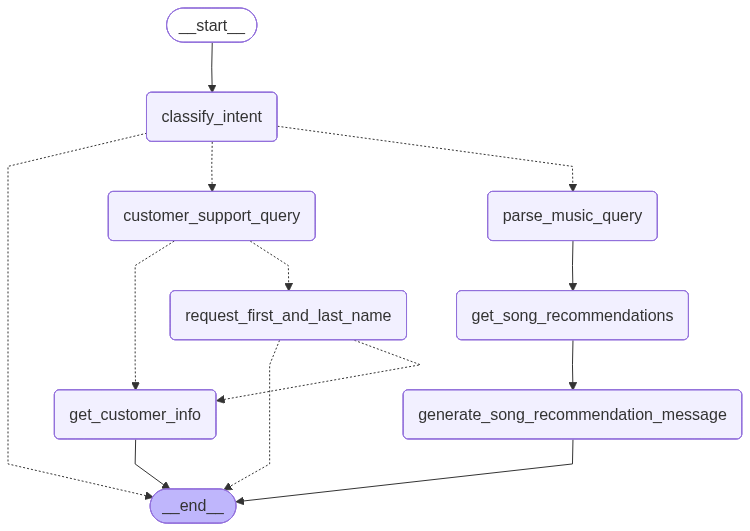

In [23]:
display(Image(graph.get_graph().draw_mermaid_png()))

## Test

In [24]:
# Simulate incoming message
message_id += 1

initial_message = MessageAgentState(
    message_content="I need customer support",
    message_id=message_id,
    sender_number="+44 020 7976 5722",
)

config = {"configurable": {"thread_id": str(message_id)}}
result = graph.invoke(initial_message, config=config)
# result = graph.invoke(Command(resume="Phil Hughes"), config=config)
print(result)

Message classification: intent='customer_support_query'
Handling customer support query for: I need customer support
Extracted customer name: first_name=None last_name=None
Prompting for customer name. Current state: message_content='I need customer support' followup_message=None message_id=2 sender_number='+44 020 7976 5722' message_classification=MessageClassification(intent='customer_support_query') music_query=None song_recommendations=[] agent_message='Thank you for reaching out to customer support. Before I continue, please reply with your first and last name.' customer_first_name=None customer_last_name=None customer_verified=False customer_document=None
{'message_content': 'I need customer support', 'message_id': 2, 'sender_number': '+44 020 7976 5722', 'message_classification': MessageClassification(intent='customer_support_query'), 'song_recommendations': [], 'agent_message': 'Thank you for reaching out to customer support. Before I continue, please reply with your first and 

In [25]:
# The graph will pause at human_review
print(f"Agent message: {result['agent_message']}")

Agent message: Thank you for reaching out to customer support. Before I continue, please reply with your first and last name.


In [34]:
# Provide human input to resume
human_response = Command(resume={"followup_message": "Phil Hughes"})

# Resume execution
final_result = graph.invoke(human_response, config)

Prompting for customer name. Current state: message_content='I need customer support' followup_message=None message_id=2 sender_number='+44 020 7976 5722' message_classification=MessageClassification(intent='customer_support_query') music_query=None song_recommendations=[] agent_message='Thank you for reaching out to customer support. Before I continue, please reply with your first and last name.' customer_first_name=None customer_last_name=None customer_verified=False customer_document=None
Customer follow-up message: Phil Hughes
Extracted customer name from follow-up: first_name='Phil' last_name='Hughes'
Fetching customer info for: Phil Hughes
get_customer_by_name: first_name=Phil, last_name=Hughes
Checking customer_id=53 phone=+44 020 7976 5722 against sender_number=+44 020 7976 5722
Verified matching customer found: {'customer_id': 53, 'first_name': 'Phil', 'last_name': 'Hughes', 'company': None, 'address': '113 Lupus St', 'city': 'London', 'state': None, 'country': 'United Kingdom

/Users/mako/.pyenv/versions/langchain/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `CustomerDocument` - serialized value may not be as expected [field_name='customer_document', input_value={'customer_id': 53, 'firs...m', 'support_rep_id': 3}, input_type=dict])
  return self.__pydantic_serializer__.to_python(


In [27]:
# # Simulate incoming message
# message_id += 1

# initial_message = MessageAgentState(
#     message_content="I need customer support, my name is Phil Hughes",
#     message_id=message_id,
#     sender_number="+44 020 7976 5722",
# )

# config = {"configurable": {"thread_id": str(message_id)}}
# result = graph.invoke(initial_message, config=config)
# # result = graph.invoke(Command(resume="Phil Hughes"), config=config)
# print(result)

In [28]:
# # Simulate incoming message
# message_id += 1

# initial_message = MessageAgentState(
#     message_content="Find me music like AC/DC but not like Prince",
#     message_id=message_id,
#     sender_number="555-123-1234",
# )

# config = {"configurable": {"thread_id": str(message_id)}}
# result = graph.invoke(initial_message, config=config)

In [29]:
# # Simulate incoming message
# message_id += 1

# initial_message = MessageAgentState(
#     message_content="Songs like bohemian rhapsody and what a wonderful world",
#     message_id=message_id,
#     sender_number="555-123-1234",
# )

# config = {"configurable": {"thread_id": str(message_id)}}
# result = graph.invoke(initial_message, config=config)

In [30]:
# # Simulate incoming message
# message_id += 1

# initial_message = MessageAgentState(
#     message_content="Songs like classical and I want it that way",
#     message_id=message_id,
#     sender_number="555-123-1234",
# )

# config = {"configurable": {"thread_id": str(message_id)}}
# result = graph.invoke(initial_message, config=config)

In [31]:
# # Simulate incoming message
# message_id += 1

# initial_message = MessageAgentState(
#     message_content="Songs like Yellow, but not Coldplay deep cuts",
#     message_id=message_id,
#     sender_number="555-123-1234",
# )

# config = {"configurable": {"thread_id": str(message_id)}}
# result = graph.invoke(initial_message, config=config)

In [32]:
# # Simulate incoming message
# message_id += 1

# initial_message = MessageAgentState(
#     message_content="Recommend me some music",
#     message_id=message_id,
#     sender_number="555-123-1234",
# )

# config = {"configurable": {"thread_id": str(message_id)}}
# result = graph.invoke(initial_message, config=config)

In [33]:
# # Simulate incoming message
# message_id += 1

# initial_message = MessageAgentState(
#     message_content="Recommend me some music from jkdlasjflkanf32jnfeja",
#     message_id=message_id,
#     sender_number="555-123-1234",
# )

# config = {"configurable": {"thread_id": str(message_id)}}
# result = graph.invoke(initial_message, config=config)